In [ ]:
# Import libraries. You may or may not use all of these.
!pip install -q git+https://github.com/tensorflow/docs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_docs.modeling

  Preparing metadata (setup.py) ... done
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [ ]:
# Import data
!wget https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
dataset = pd.read_csv('insurance.csv')
dataset.tail()
len(dataset)

--2025-04-08 13:49:59--  https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 104.26.2.33, 104.26.3.33, 172.67.70.149, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|104.26.2.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50264 (49K) [text/csv]
Saving to: ‘insurance.csv’

insurance.csv       100%[===================>]  49.09K  --.-KB/s    in 0.008s  

2025-04-08 13:49:59 (5.77 MB/s) - ‘insurance.csv’ saved [50264/50264]



1338

In [ ]:
dataset.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [ ]:
#Converting categorical values to numeric
df = dataset
df["sex"] = pd.factorize(df["sex"])[0]
df["region"] = pd.factorize(df["region"])[0]
df["smoker"] = pd.factorize(df["smoker"])[0]
dataset = df
dataset.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,0,27.9,0,0,0,16884.92
1,18,1,33.8,1,1,1,1725.55
2,28,1,33.0,3,1,1,4449.46
3,33,1,22.7,0,1,2,21984.47
4,32,1,28.9,0,1,2,3866.86


In [ ]:
from sklearn.model_selection import train_test_split


labels = dataset.pop("expenses")

# Split the data into 80% training and 20% testing
train_dataset, test_dataset, train_labels, test_labels = train_test_split(
    dataset, labels, test_size=0.2, random_state=42
)

In [ ]:
from tensorflow.keras.layers import Normalization

# Create and adapt normalization layer
normalizer = Normalization()
normalizer.adapt(np.array(train_dataset))

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# Define the model
model = keras.Sequential([
    normalizer,
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # Safer learning rate
    loss='mae',
    metrics=['mae', 'mse']
)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    train_labels,
    validation_split=0.2,
    epochs=100,
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 13214.4307 - mae: 13214.4307 - mse: 308686112.0000 - val_loss: 12653.1670 - val_mae: 12653.1670 - val_mse: 310298880.0000
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13617.8652 - mae: 13617.8652 - mse: 330411104.0000 - val_loss: 12647.8223 - val_mae: 12647.8223 - val_mse: 310149088.0000
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12900.8828 - mae: 12900.8828 - mse: 298505824.0000 - val_loss: 12636.2334 - val_mae: 12636.2334 - val_mse: 309827520.0000
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12666.4141 - mae: 12666.4141 - mse: 288974656.0000 - val_loss: 12614.3174 - val_mae: 12614.3174 - val_mse: 309226400.0000
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13308.4150 - mae: 13308.4150 - mse: 317706208.0000 - val_loss: 12577.4766 - val_mae: 12577.4766 - val_mse: 308222656.0000
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 14044.7998 - mae: 14044.7998 - mse:

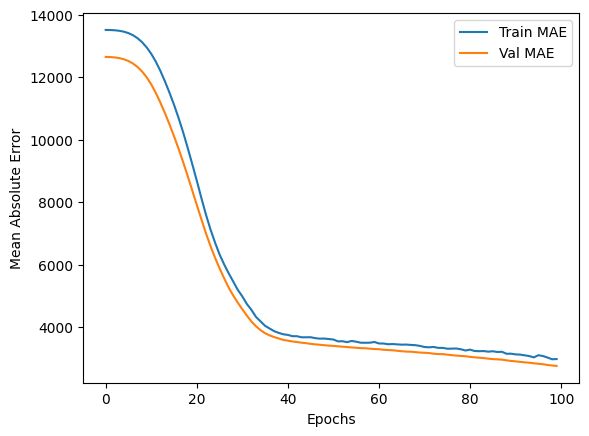

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()


9/9 - 0s - 6ms/step - loss: 2729.6733 - mae: 2729.6733 - mse: 30063576.0000
Testing set Mean Abs Error: 2729.67 expenses
You passed the challenge. Great job!
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


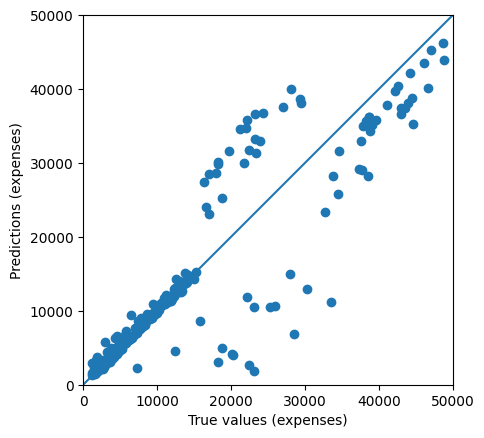

In [ ]:
# Test model by checking how well the model generalizes using the test set.
loss, mae, mse = model.evaluate(test_dataset, test_labels, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 3500:
  print("You passed the challenge. Great job!")
else:
  print("The Mean Abs Error must be less than 3500. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_dataset).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True values (expenses)')
plt.ylabel('Predictions (expenses)')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims,lims)


After training and tuning the model, I evaluated it on the test dataset.
The final Mean Absolute Error (MAE) on the test set is $2729.67. It is below the $3500 threshold meaning the challange passed successfully.
The scatter plot shows the relationship between the true expenses and the predicted ones. The diagonal line represents perfect predictions. Most of the points are close to this line, especially for lower and mid-range expense values, which indicates the model has learned well.
There are a few larger deviations for high cost individuals, which is expected in real-world data due to their complexity and variation. Still, the predictions follow the general trend quite well.
Overall, the model performs reliably and generalizes well on unseen data.
